# QAOA Comparison Framework: ADAPT vs GPT (Scalable)

In [19]:
# ------------------------
# IMPORTS
# ------------------------

import random
import numpy as np
import torch
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from pathlib import Path

from adapt_utils import get_combined_res_df
from model_interface import QAOA_GPT

pd.set_option("display.max_columns", None)

In [ ]:
# ------------------------
# CONFIG
# ------------------------

SEED = 1337

# ADAPT
data_input_path = "./ADAPT.jl_results/test/9_nodes"

# MODEL CONFIG (can extend later)
MODEL_CONFIGS = [
    dict(
        name="GPT-Feather",
        ckpt="nanoGPT/out-9_nodes_feather/gpt_ckpt_3500_feather_ar_0_95709__er_0_0.pt",
        data_dir="nanoGPT/data/9_nodes_feather",
    ),
]

# GENERATION
N_SAMPLES = 5
MAX_TOKENS = 150

In [21]:
# ------------------------
# SEED
# ------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [22]:
# ------------------------
# GRAPH UTILS
# ------------------------

def edgelist_to_nx(edgelist, n_nodes):
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))

    for u, v, w in edgelist:
        G.add_edge(u - 1, v - 1, weight=w)

    return G


def load_graphs_from_adapt(adapt_df):
    graphs, meta = [], []

    for _, row in adapt_df.iterrows():
        G = edgelist_to_nx(row["edgelist_list"], row["n_nodes"])
        graphs.append(G)

        meta.append({
            "graph_name": row["graph_name"],
            "adapt_ar": row["approx_ratio"],
            "adapt_layers": row["n_layers"],
        })

    return graphs, pd.DataFrame(meta)

In [23]:
# ------------------------
# MODEL UTILS
# ------------------------

def load_model(cfg):
    return QAOA_GPT(
        model_ckpt=cfg["ckpt"],
        data_dir=cfg["data_dir"],
        temp_folder="temp_data",
    )


def run_model(qaoa, graphs):
    df_model = qaoa.generate_circ_from_nx(
        graphs,
        num_samples=N_SAMPLES,
        max_new_tokens=MAX_TOKENS,
        temperature=0.1,
        top_k=200,
    )

    return qaoa.eval_circ_df_jl(df_model)


def compute_model_metrics(df):

    df_expl = df.explode(["adapt_gpt_energies", "q_circuits"])

    # layers
    layers = df_expl["q_circuits"].apply(
        lambda x: x.count("new_layer_p")
    )

    # energy
    df_energy = df[
        ["adapt_gpt_energies", "energy_gurobi"]
    ].explode("adapt_gpt_energies")

    df_corr = df_energy[
        df_energy["adapt_gpt_energies"] != 999
    ].copy()

    df_corr["ar"] = (
        df_corr["adapt_gpt_energies"]
        / df_corr["energy_gurobi"]
    )

    return (
        df_corr.groupby(level=0)["ar"].mean(),
        layers.groupby(level=0).mean(),
    )

In [ ]:
# ------------------------
# LOAD ADAPT
# ------------------------

adapt_df = get_combined_res_df(
    data_input_path,
    debug_limit=None,
)

graphs, meta_df = load_graphs_from_adapt(adapt_df)

Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/9_nodes


Opening ADAPT results (9_nodes): 100%|██████████| 1/1 [00:00<00:00, 51.34it/s]


df_list len: 1


Opening graphs (9_nodes): 100%|██████████| 1/1 [00:00<00:00, 276.01it/s]

df_list len: 1
Graphs count:
g_method
erdos_renyi    100
Name: count, dtype: int64
Aggregating results...


In [25]:
# ------------------------
# RUN ALL MODELS
# ------------------------

all_results = []

for cfg in MODEL_CONFIGS:

    print(f"Running {cfg['name']}")

    model = load_model(cfg)
    df_eval = run_model(model, graphs)

    model_ar, model_layers = compute_model_metrics(df_eval)

    res_df = pd.DataFrame({
        "graph_name": meta_df["graph_name"],
        "model": cfg["name"],
        "model_ar": model_ar.values,
        "model_layers": model_layers.values,
    })

    all_results.append(res_df)

model_results_df = pd.concat(all_results, ignore_index=True)

Running GPT-Feather

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 9
Initiating nanoGPT model with padding support
number of parameters: 11.66M


Preparing graphs...: 100%|██████████| 134/134 [00:00<00:00, 390.37it/s]


Performing feather embedding


100%|██████████| 134/134 [00:00<00:00, 1926.99it/s]
Inference. Current batch: n_edges: 30, n_graphs: 1: 100%|██████████| 27/27 [00:27<00:00,  1.00s/it]



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-03-31__21_56_09_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-03-31__21_56_09_df_jl.json 9 qaoa_double_pool


Julia return code: 0


In [31]:
# ------------------------
# MERGE WITH ADAPT
# ------------------------

final_df = meta_df.merge(
    model_results_df,
    on="graph_name"
)

final_df["ar_diff"] = final_df["model_ar"] - final_df["adapt_ar"]
final_df["layer_diff"] = final_df["model_layers"] - final_df["adapt_layers"]

final_df.head(10)

,graph_name,adapt_ar,adapt_layers,model,model_ar,model_layers,ar_diff,layer_diff
0,Graph_1,0.980812,7,GPT-Feather,0.94556,9.8,-0.035252,2.8
1,Graph_2,0.938188,25,GPT-Feather,0.944859,9.6,0.00667,-15.4
2,Graph_2,0.938188,25,GPT-Feather,0.938528,6.8,0.00034,-18.2
3,Graph_2,0.972626,16,GPT-Feather,0.944859,9.6,-0.027768,-6.4
4,Graph_2,0.972626,16,GPT-Feather,0.938528,6.8,-0.034098,-9.2
5,Graph_3,0.927495,25,GPT-Feather,0.933025,6.8,0.00553,-18.2
6,Graph_3,0.927495,25,GPT-Feather,0.961295,9.0,0.033799,-16.0
7,Graph_3,0.970004,13,GPT-Feather,0.933025,6.8,-0.036979,-6.2
8,Graph_3,0.970004,13,GPT-Feather,0.961295,9.0,-0.008709,-4.0
9,Graph_4,0.971510,7,GPT-Feather,0.968535,8.8,-0.002975,1.8


In [27]:
# ------------------------
# SUMMARY TABLE
# ------------------------

summary_df = final_df.groupby("model").agg({
    "adapt_ar": "mean",
    "model_ar": "mean",
    "adapt_layers": "mean",
    "model_layers": "mean",
    "ar_diff": "mean",
    "layer_diff": "mean",
}).reset_index()

summary_df

,model,adapt_ar,model_ar,adapt_layers,model_layers,ar_diff,layer_diff
0,GPT-Feather,0.964762,0.950497,15.84434,9.309434,-0.014264,-6.534906


In [28]:
# ------------------------
# PLOTTING FUNCTIONS
# ------------------------

def plot_bar_avg(df):

    x = np.arange(len(df["model"]))

    plt.figure()
    plt.bar(x - 0.15, df["adapt_ar"], width=0.3, label="ADAPT")
    plt.bar(x + 0.15, df["model_ar"], width=0.3, label="MODEL")

    plt.xticks(x, df["model"])
    plt.ylabel("Approximation Ratio")
    plt.title("Average Approximation Ratio")

    plt.legend()
    plt.grid()
    plt.show()


def plot_bar_layers(df):

    x = np.arange(len(df["model"]))

    plt.figure()
    plt.bar(x - 0.15, df["adapt_layers"], width=0.3, label="ADAPT")
    plt.bar(x + 0.15, df["model_layers"], width=0.3, label="MODEL")

    plt.xticks(x, df["model"])
    plt.ylabel("Layers")
    plt.title("Average Layers")

    plt.legend()
    plt.grid()
    plt.show()


def plot_scatter_tradeoff(df):

    plt.figure()

    plt.scatter(
        df["adapt_layers"],
        df["adapt_ar"],
        label="ADAPT",
    )

    plt.scatter(
        df["model_layers"],
        df["model_ar"],
        label="MODEL",
    )

    plt.xlabel("Layers")
    plt.ylabel("Approximation Ratio")
    plt.title("AR vs Layers Tradeoff")

    plt.legend()
    plt.grid()
    plt.show()


def plot_per_graph(final_df):

    plt.figure()
    plt.plot(final_df["adapt_ar"].values, label="ADAPT")
    plt.plot(final_df["model_ar"].values, label="MODEL")
    plt.title("AR per graph")
    plt.legend()
    plt.grid()
    plt.show()

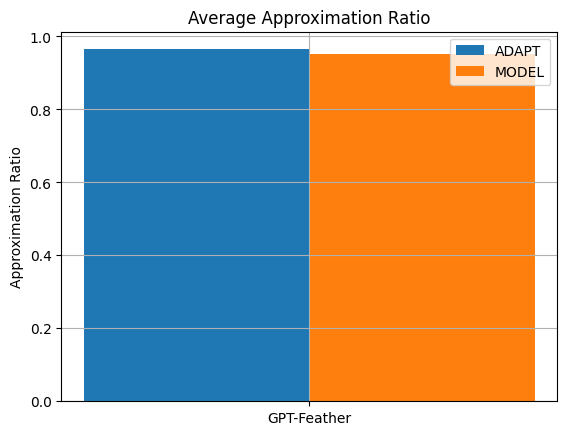

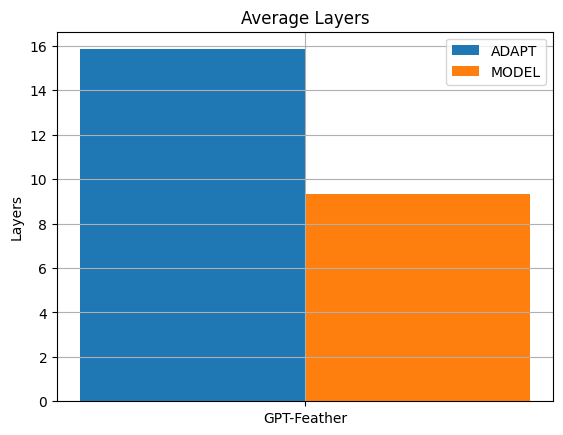

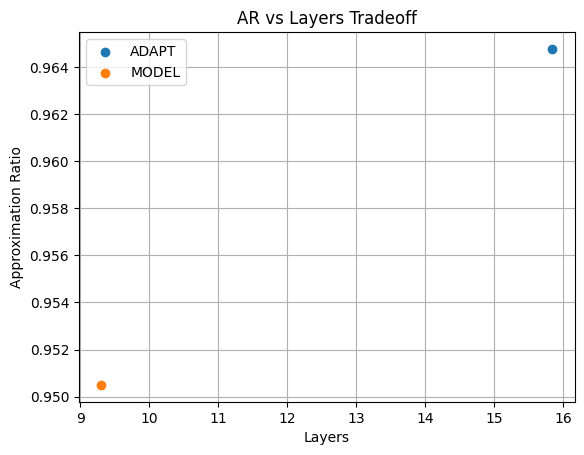

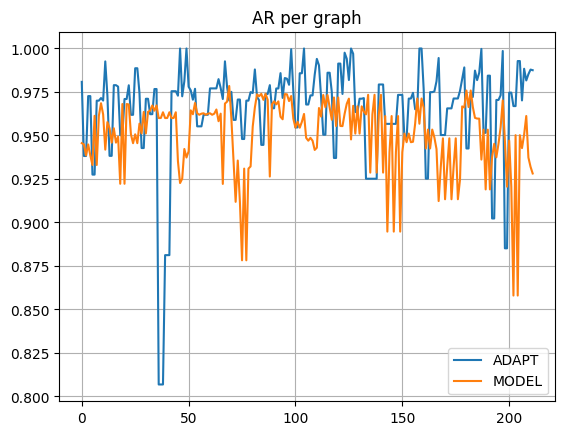

In [29]:
# ------------------------
# RUN PLOTS
# ------------------------

plot_bar_avg(summary_df)
plot_bar_layers(summary_df)
plot_scatter_tradeoff(summary_df)
plot_per_graph(final_df)

In [30]:
# ------------------------
# INSIGHTS
# ------------------------

print("===== INSIGHTS =====")

print("\nAvg ADAPT AR:", summary_df["adapt_ar"].mean())
print("Avg MODEL AR:", summary_df["model_ar"].mean())

print("\nAvg ADAPT Layers:", summary_df["adapt_layers"].mean())
print("Avg MODEL Layers:", summary_df["model_layers"].mean())

print("\nKey Observation:")

if summary_df["model_ar"].mean() > summary_df["adapt_ar"].mean():
    print("- Model outperforms ADAPT in approximation ratio")
else:
    print("- ADAPT still stronger in approximation ratio")

if summary_df["model_layers"].mean() < summary_df["adapt_layers"].mean():
    print("- Model produces shallower circuits")
else:
    print("- Model circuits are deeper")

print("\nTradeoff:")
print("- Check scatter plot: better models sit TOP-LEFT (high AR, low layers)")

===== INSIGHTS =====

Avg ADAPT AR: 0.9647615519294777
Avg MODEL AR: 0.9504974331272605

Avg ADAPT Layers: 15.84433962264151
Avg MODEL Layers: 9.309433962264151

Key Observation:
- ADAPT still stronger in approximation ratio
- Model produces shallower circuits

Tradeoff:
- Check scatter plot: better models sit TOP-LEFT (high AR, low layers)
